# Battery Baseline Analysis — EV01
**Purpose:** Understand the real distribution of temperature, voltage, and current across 1.6M timestamps.  
Use percentiles and visual distributions to validate or tune alert thresholds in `battery_intelligence/config.py`.

| Section | Content |
|---------|----------|
| 1 | Dataset overview |
| 2 | Temperature — pack & module |
| 3 | Current — charge / discharge |
| 4 | Voltage — pack, cell, spread |
| 5 | Per-module comparison |
| 6 | Scatter plots — joint stress |
| 7 | Outlier deep-dive |
| 8 | Threshold review |


In [3]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from configs.settings import DATA_DIR

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (14, 5)})
PERCENTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
PCT_LABELS  = ['p1','p5','p10','p25','p50','p75','p90','p95','p99']

MODULES = [1, 2, 3, 4, 5]

def pct_table(df, cols, label='Percentile table'):
    """Return a styled percentile + stats table for a list of columns."""
    stats = df[cols].describe(percentiles=PERCENTILES).T
    stats.index.name = 'metric'
    return stats.round(3)

print('Libraries loaded.')

Libraries loaded.


In [4]:
# ── Load master dataset (all 89 partitions) ─────────────────────────────────
master_dir = DATA_DIR / 'analysis' / 'master'
files = sorted(master_dir.rglob('*.parquet'))
print(f'Partitions found: {len(files)}')

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df = df.sort_values('timestamp').reset_index(drop=True)

# Millivolt helpers
for m in MODULES:
    df[f'module_{m}_voltage_range_mv'] = df[f'module_{m}_voltage_range'] * 1000
df['pack_voltage_range_mv'] = df['pack_voltage_range'] * 1000
df['cell_spread_mv']        = df['cell_spread_v'] * 1000

print(f'Total rows  : {len(df):,}')
print(f'Date range  : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Columns     : {df.shape[1]}')
df[['timestamp','soc_pct','battery_current_a','abs_current_a',
    'avg_battery_temp_c','max_battery_temp_c','avg_cell_voltage_v']].describe().round(2)

Partitions found: 89
Total rows  : 1,643,119
Date range  : 2026-01-22 → 2026-05-17
Columns     : 75


,timestamp,soc_pct,battery_current_a,abs_current_a,avg_battery_temp_c,max_battery_temp_c,avg_cell_voltage_v
count,1643119,1636938.00,1634544.00,1634544.00,1594373.00,1594384.00,1524505.00
mean,2026-03-22 00:02:45.977346048,75.81,43.57,43.57,33.88,39.20,3.32
min,2026-01-22 15:21:36,0.00,0.00,0.00,0.00,0.00,0.00
25%,2026-02-16 23:23:05,63.00,11.00,11.00,31.50,35.60,3.29
50%,2026-03-14 23:46:55,78.00,15.00,15.00,34.00,39.20,3.31
75%,2026-04-19 14:16:24.500000,91.00,73.00,73.00,36.60,43.00,3.34
max,2026-05-17 23:59:59,100.00,1451.00,1451.00,74.00,231.00,3.53
std,NaN,18.00,46.99,46.99,4.31,5.43,0.06


---
## 1 · Dataset Overview

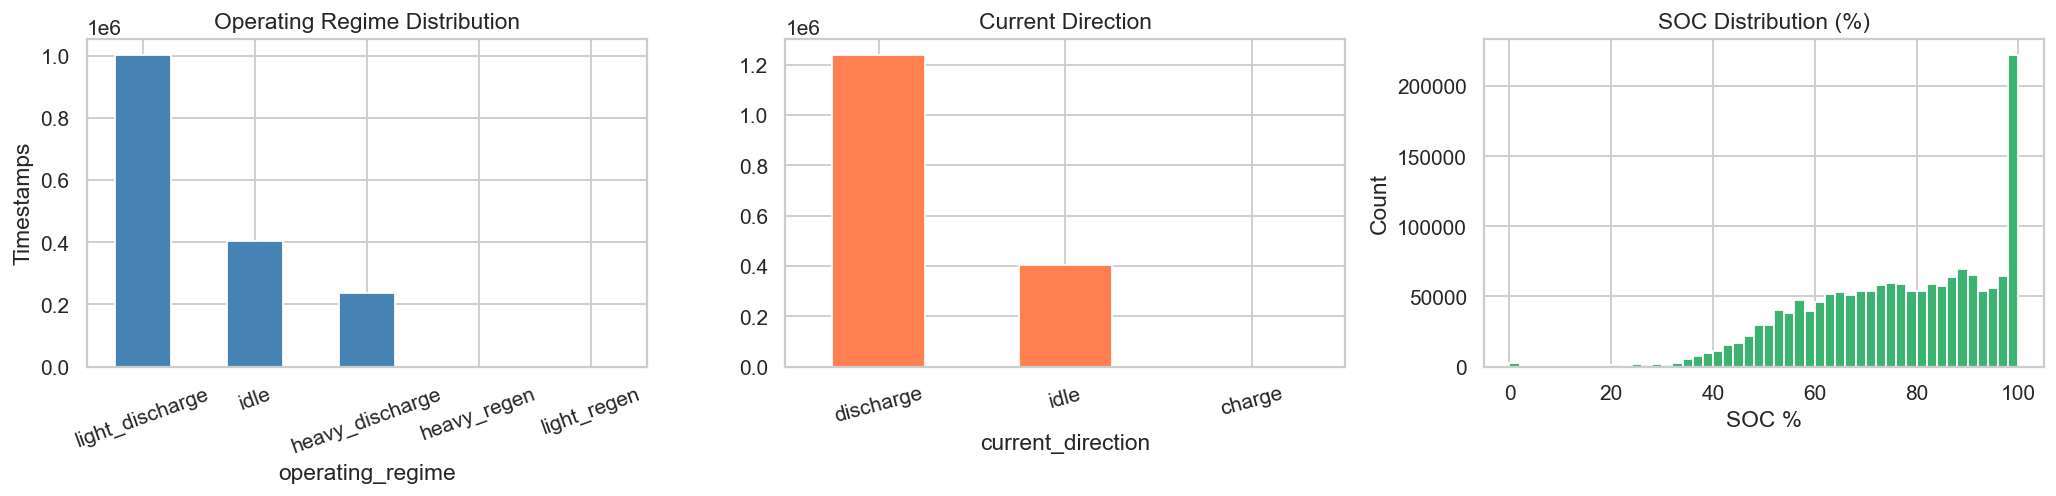

Clean rows: 1643119 (100.0%)
Fault rows: 79437 (4.8%)


In [5]:
# Operating regime and data quality breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Operating regime
df['operating_regime'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Operating Regime Distribution')
axes[0].set_ylabel('Timestamps')
axes[0].tick_params(axis='x', rotation=20)

# Current direction
df['current_direction'].value_counts().plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Current Direction')
axes[1].tick_params(axis='x', rotation=15)

# SOC distribution
axes[2].hist(df['soc_pct'].dropna(), bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('SOC Distribution (%)')
axes[2].set_xlabel('SOC %')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Clean rows:', df['is_clean'].sum(), f'({100*df["is_clean"].mean():.1f}%)')
print('Fault rows:', df['fault_any'].sum(), f'({100*df["fault_any"].mean():.1f}%)')

---
## 2 · Temperature Analysis
Key columns: `max_battery_temp_c`, `min_battery_temp_c`, `avg_battery_temp_c`, `pack_temp_range`

**Current thresholds in config:**  
- Warn: 45°C | High: 50°C | Critical: 55°C  
- Temp imbalance low: 6°C | medium: 12°C | high: 18°C

In [6]:
temp_cols = ['max_battery_temp_c', 'avg_battery_temp_c', 'min_battery_temp_c', 'pack_temp_range']
pct_table(df, temp_cols)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
max_battery_temp_c,1594384.0,39.201,5.431,0.0,29.0,29.4,31.9,35.6,39.2,43.0,46.1,48.0,51.1,231.0
avg_battery_temp_c,1594373.0,33.877,4.306,0.0,22.4,25.7,28.8,31.5,34.0,36.6,39.0,41.0,44.0,74.0
min_battery_temp_c,1594384.0,28.699,5.256,0.0,11.0,20.4,28.0,28.0,28.0,28.0,37.0,39.0,42.0,46.0
pack_temp_range,1643116.0,10.653,7.259,1.0,2.0,3.0,3.0,5.0,10.0,14.0,19.0,23.0,39.0,117.0


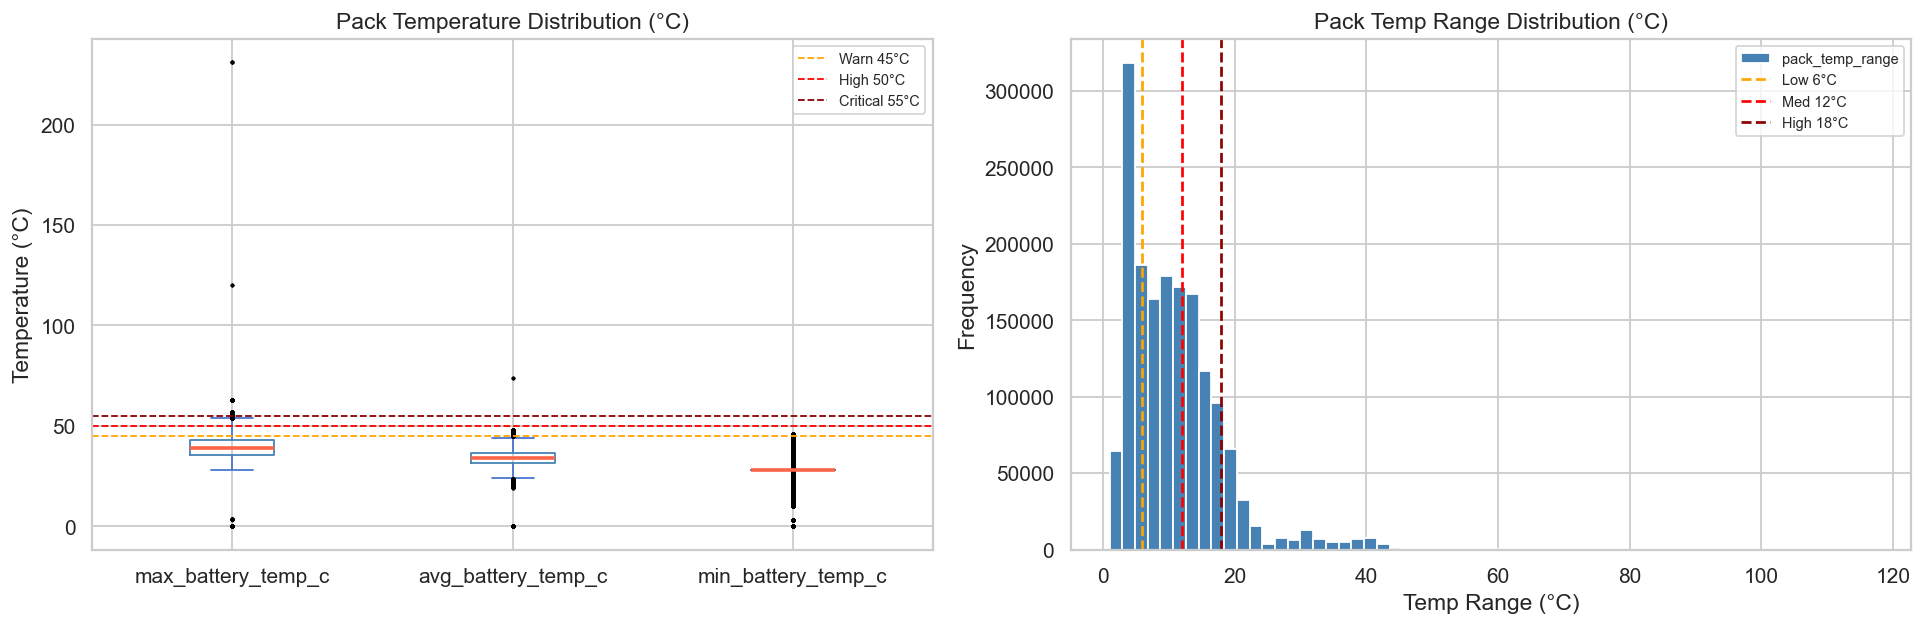

In [7]:
# Box plots — pack temperature
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df[temp_cols[:3]].plot.box(
    ax=axes[0], vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='tomato', linewidth=2),
    flierprops=dict(marker='.', color='tomato', alpha=0.3, markersize=2)
)
axes[0].set_title('Pack Temperature Distribution (°C)')
axes[0].set_ylabel('Temperature (°C)')
# Draw threshold lines
for val, lbl, clr in [(45,'Warn','orange'),(50,'High','red'),(55,'Critical','darkred')]:
    axes[0].axhline(val, color=clr, linestyle='--', linewidth=1, label=f'{lbl} {val}°C')
axes[0].legend(fontsize=8)

df['pack_temp_range'].plot.hist(ax=axes[1], bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Pack Temp Range Distribution (°C)')
axes[1].set_xlabel('Temp Range (°C)')
for val, lbl, clr in [(6,'Low','orange'),(12,'Med','red'),(18,'High','darkred')]:
    axes[1].axvline(val, color=clr, linestyle='--', linewidth=1.5, label=f'{lbl} {val}°C')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

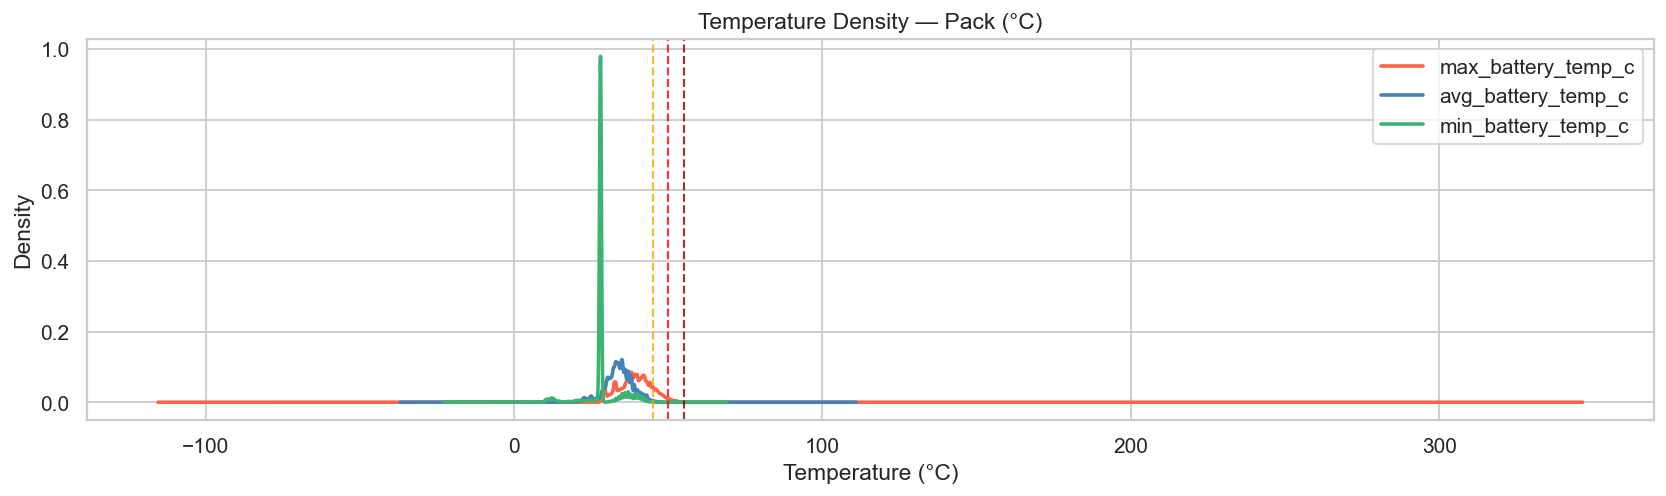

=== Threshold Exceedance ===
  max_temp > 40°C :  686,595  (41.79%)
  max_temp > 45°C :  214,627  (13.06%)
  max_temp > 50°C :   30,066  (1.83%)
  max_temp > 55°C :    1,369  (0.08%)


In [8]:
# KDE distributions for max, avg, min temp
fig, ax = plt.subplots(figsize=(13, 4))
for col, clr in zip(temp_cols[:3], ['tomato','steelblue','mediumseagreen']):
    df[col].dropna().plot.kde(ax=ax, label=col, color=clr, linewidth=2)
for val, clr in [(45,'orange'),(50,'red'),(55,'darkred')]:
    ax.axvline(val, color=clr, linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('Temperature Density — Pack (°C)')
ax.set_xlabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# What % of timestamps exceed each threshold?
print('=== Threshold Exceedance ===')
for thr in [40, 45, 50, 55]:
    n = (df['max_battery_temp_c'] > thr).sum()
    print(f'  max_temp > {thr}°C : {n:>8,}  ({100*n/len(df):.2f}%)')

In [9]:
# Per-module avg temperature comparison
mod_temp_cols = [f'module_{m}_temp_mean' for m in MODULES]
pct_table(df, mod_temp_cols)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
module_1_temp_mean,1643112.0,36.242,4.680,18.667,24.333,28.611,29.944,32.944,36.444,39.667,42.222,43.556,45.500,49.222
module_2_temp_mean,1643100.0,35.681,4.587,0.000,24.222,27.722,29.722,32.500,35.889,39.000,41.556,42.889,44.778,48.722
module_3_temp_mean,1643103.0,36.054,4.776,8.250,23.500,27.722,29.778,32.778,36.333,39.444,42.167,43.333,45.278,48.556
module_4_temp_mean,1643086.0,35.851,4.745,8.250,23.556,27.500,29.667,32.556,36.111,39.167,41.944,43.111,45.000,48.000
module_5_temp_mean,1643047.0,35.178,4.467,18.200,23.833,27.500,29.222,32.111,35.444,38.333,40.889,41.944,43.778,46.556


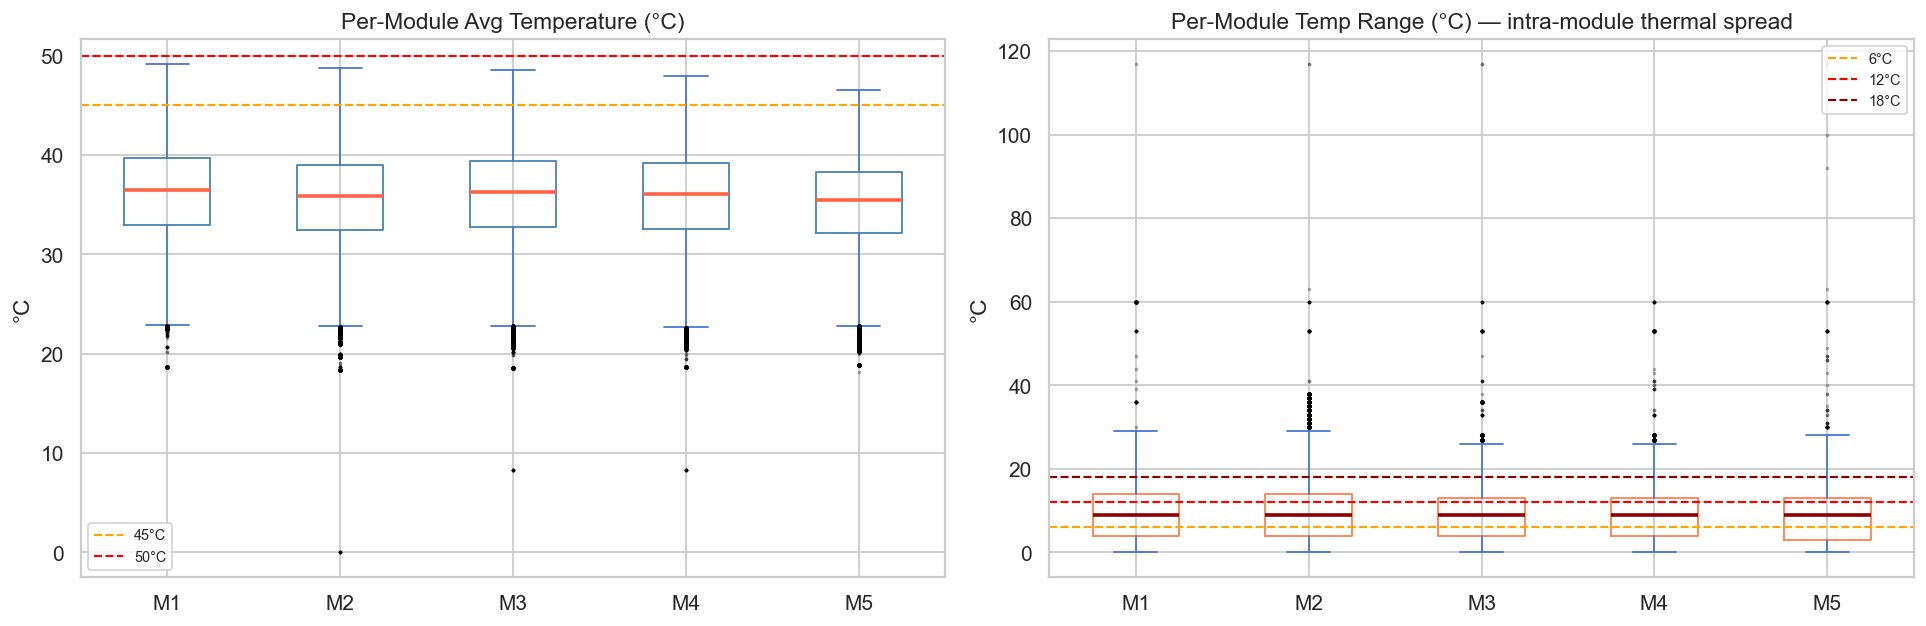

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot — per-module avg temp
df[mod_temp_cols].rename(columns={f'module_{m}_temp_mean': f'M{m}' for m in MODULES}).plot.box(
    ax=axes[0], vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='tomato', linewidth=2),
    flierprops=dict(marker='.', color='tomato', alpha=0.3, markersize=2)
)
axes[0].set_title('Per-Module Avg Temperature (°C)')
axes[0].set_ylabel('°C')
for val, clr in [(45,'orange'),(50,'red')]:
    axes[0].axhline(val, color=clr, linestyle='--', linewidth=1.2, label=f'{val}°C')
axes[0].legend(fontsize=8)

# Module temp range boxes
mod_trange_cols = [f'module_{m}_temp_range' for m in MODULES]
df[mod_trange_cols].rename(columns={f'module_{m}_temp_range': f'M{m}' for m in MODULES}).plot.box(
    ax=axes[1], vert=True,
    boxprops=dict(color='coral'),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='.', color='coral', alpha=0.3, markersize=2)
)
axes[1].set_title('Per-Module Temp Range (°C) — intra-module thermal spread')
axes[1].set_ylabel('°C')
for val, clr in [(6,'orange'),(12,'red'),(18,'darkred')]:
    axes[1].axhline(val, color=clr, linestyle='--', linewidth=1.2, label=f'{val}°C')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 3 · Current Analysis
Key columns: `battery_current_a` (signed: + discharge, − charge), `abs_current_a`

**Current thresholds in config:**  
- Stress low: 50A | medium: 100A | high: 180A  
- Rule high_current: 100A | extreme: 180A

In [11]:
curr_cols = ['battery_current_a', 'abs_current_a']
pct_table(df, curr_cols)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
battery_current_a,1634544.0,43.571,46.987,0.0,0.0,0.0,0.0,11.0,15.0,73.0,122.0,147.0,165.0,1451.0
abs_current_a,1634544.0,43.571,46.987,0.0,0.0,0.0,0.0,11.0,15.0,73.0,122.0,147.0,165.0,1451.0


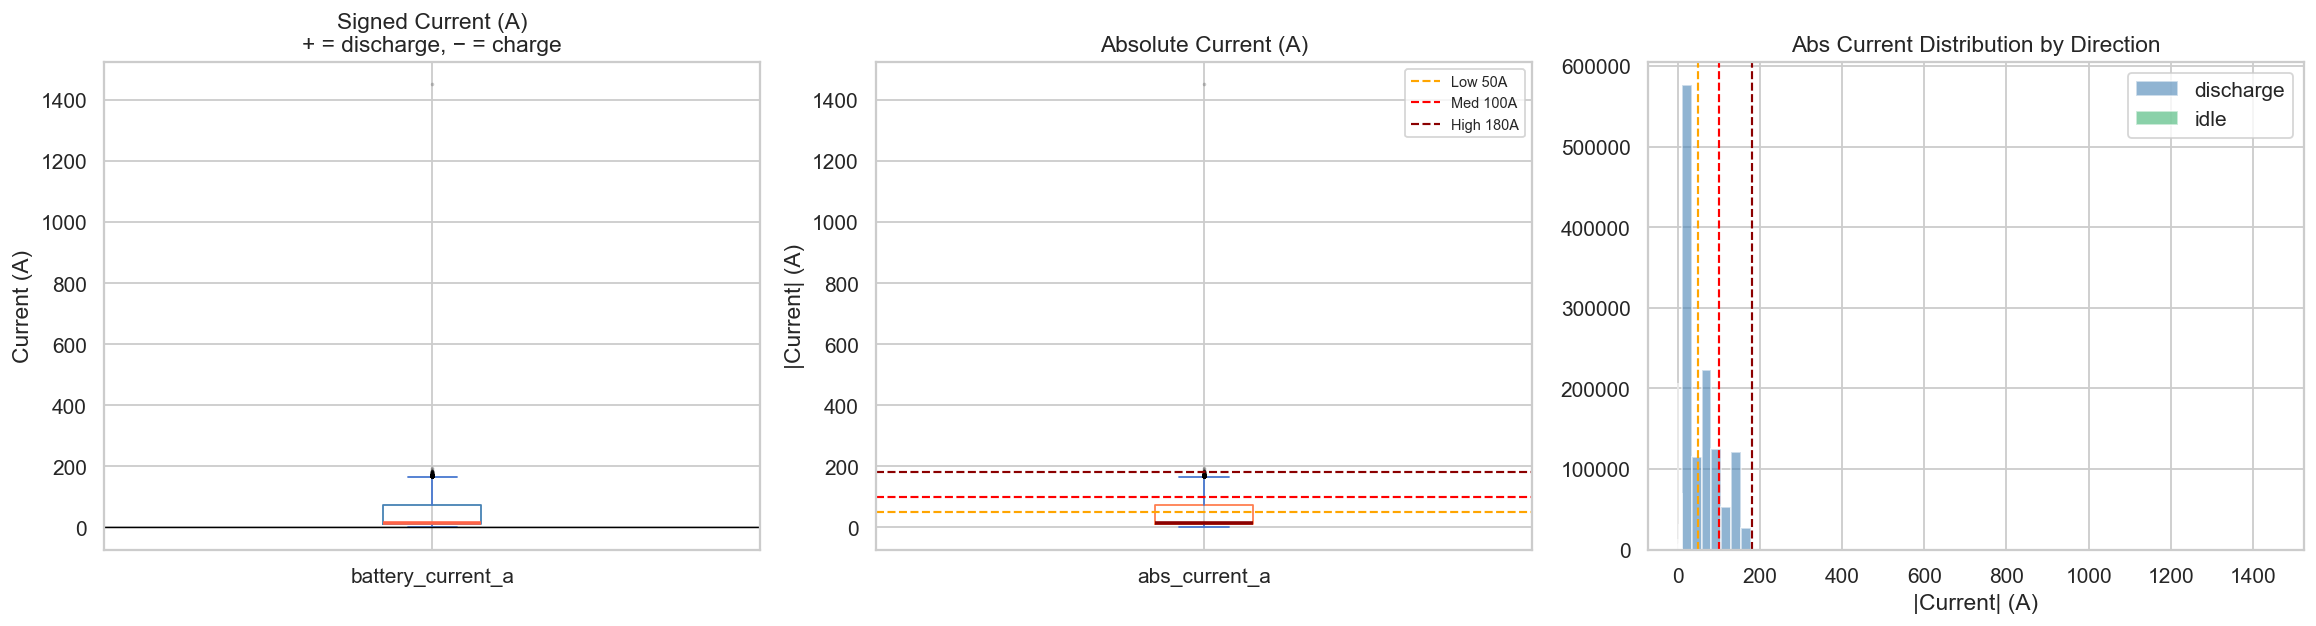

=== Current Threshold Exceedance ===
  abs_current >  50A :  597,247  (36.35%)
  abs_current > 100A :  230,788  (14.05%)
  abs_current > 150A :   39,552  (2.41%)
  abs_current > 180A :       13  (0.00%)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot — signed current
df['battery_current_a'].plot.box(
    ax=axes[0], vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='tomato', linewidth=2),
    flierprops=dict(marker='.', color='tomato', alpha=0.2, markersize=2)
)
axes[0].set_title('Signed Current (A)\n+ = discharge, − = charge')
axes[0].set_ylabel('Current (A)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='-')

# Box plot — absolute current
df['abs_current_a'].plot.box(
    ax=axes[1], vert=True,
    boxprops=dict(color='coral'),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='.', color='coral', alpha=0.2, markersize=2)
)
axes[1].set_title('Absolute Current (A)')
axes[1].set_ylabel('|Current| (A)')
for val, lbl, clr in [(50,'Low','orange'),(100,'Med','red'),(180,'High','darkred')]:
    axes[1].axhline(val, color=clr, linestyle='--', linewidth=1.2, label=f'{lbl} {val}A')
axes[1].legend(fontsize=8)

# Histogram of abs_current by direction
for direction, clr in [('discharge','steelblue'),('charge','coral'),('idle','mediumseagreen')]:
    subset = df[df['current_direction']==direction]['abs_current_a'].dropna()
    if len(subset): axes[2].hist(subset, bins=60, alpha=0.6, label=direction, color=clr)
axes[2].set_title('Abs Current Distribution by Direction')
axes[2].set_xlabel('|Current| (A)')
for val, clr in [(50,'orange'),(100,'red'),(180,'darkred')]:
    axes[2].axvline(val, color=clr, linestyle='--', linewidth=1.2)
axes[2].legend()

plt.tight_layout()
plt.show()

print('=== Current Threshold Exceedance ===')
for thr in [50, 100, 150, 180]:
    n = (df['abs_current_a'] > thr).sum()
    print(f'  abs_current > {thr:>3}A : {n:>8,}  ({100*n/len(df):.2f}%)')

In [13]:
# Current percentile by operating regime
print('=== Abs Current (A) by Operating Regime ===')
df.groupby('operating_regime')['abs_current_a'].describe(percentiles=PERCENTILES).round(1)

=== Abs Current (A) by Operating Regime ===


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
operating_regime,,,,,,,,,,,,,,
heavy_regen,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
light_regen,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idle,394276.0,3.3,4.2,0.0,0.0,0.0,0.0,0.0,0.0,9.0,10.0,10.0,10.0,10.0
light_discharge,1003468.0,37.7,28.6,10.4,11.0,11.0,11.5,13.0,19.0,63.0,81.0,89.0,99.0,99.5
heavy_discharge,236800.0,135.6,20.5,100.0,100.0,101.0,103.0,118.0,144.0,149.0,162.0,166.0,170.0,1451.0


---
## 4 · Voltage Analysis
Key columns: `avg_cell_voltage_v`, `max_cell_voltage_v`, `min_cell_voltage_v`, `cell_spread_v` (→ mV), `pack_voltage_range` (→ mV)

**Current thresholds in config:**  
- Voltage imbalance low: 40mV | medium: 80mV | high: 120mV

In [14]:
volt_cols = ['avg_cell_voltage_v','max_cell_voltage_v','min_cell_voltage_v',
             'cell_spread_mv','pack_voltage_range_mv','stack_voltage_v']
pct_table(df, volt_cols)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
avg_cell_voltage_v,1524505.0,3.318,0.060,0.00,3.226,3.260,3.273,3.291,3.313,3.339,3.388,3.395,3.412,3.534
max_cell_voltage_v,1524505.0,3.329,0.058,0.00,3.236,3.267,3.281,3.300,3.320,3.348,3.398,3.409,3.465,3.753
min_cell_voltage_v,1524505.0,3.290,0.096,0.00,3.157,3.212,3.234,3.262,3.291,3.321,3.358,3.380,3.391,3.430
cell_spread_mv,1524505.0,39.159,86.862,-3300.00,3.000,3.000,4.000,5.000,30.000,58.000,75.000,97.000,143.000,3385.000
pack_voltage_range_mv,1643115.0,42.477,42.774,2.00,3.000,4.000,4.000,11.000,36.000,62.000,80.000,103.000,143.000,3337.000
stack_voltage_v,1636615.0,593.527,7.777,233.92,577.335,583.035,585.295,588.600,592.505,596.990,606.000,607.220,610.256,636.000


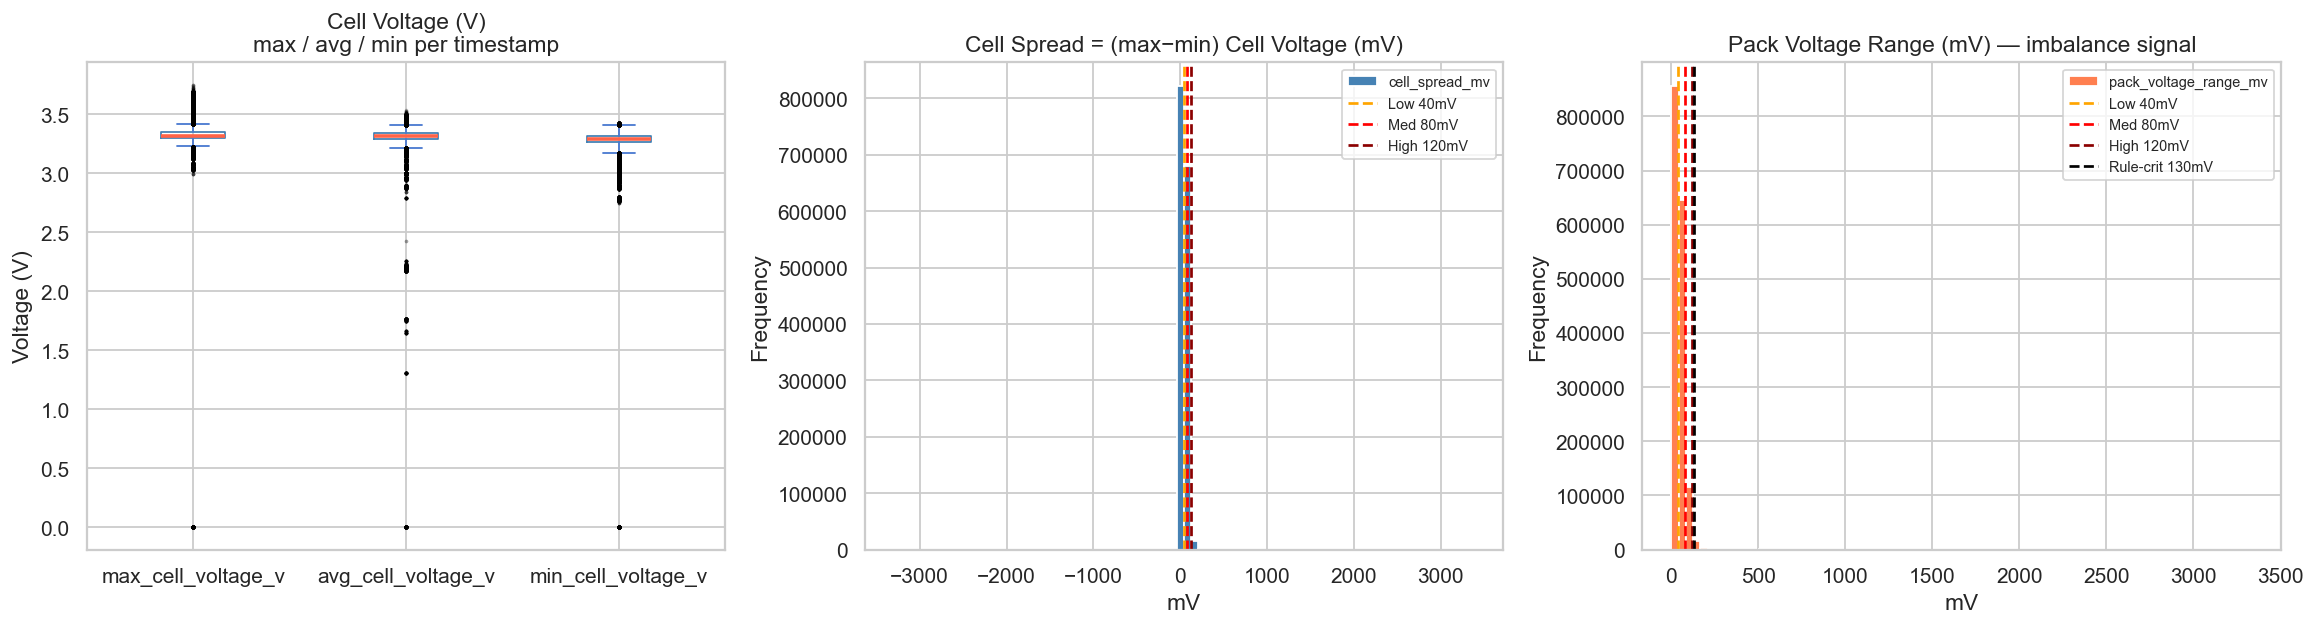

=== Pack Voltage Range Threshold Exceedance ===
  pack_voltage_range >  40mV :  804,577  (48.97%)
  pack_voltage_range >  80mV :  168,267  (10.24%)
  pack_voltage_range >  90mV :  121,920  (7.42%)
  pack_voltage_range > 120mV :   39,019  (2.37%)
  pack_voltage_range > 130mV :   22,683  (1.38%)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot — cell voltages
df[['max_cell_voltage_v','avg_cell_voltage_v','min_cell_voltage_v']].plot.box(
    ax=axes[0], vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='tomato', linewidth=2),
    flierprops=dict(marker='.', color='tomato', alpha=0.2, markersize=2)
)
axes[0].set_title('Cell Voltage (V)\nmax / avg / min per timestamp')
axes[0].set_ylabel('Voltage (V)')

# Cell spread (mV)
df['cell_spread_mv'].dropna().plot.hist(ax=axes[1], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Cell Spread = (max−min) Cell Voltage (mV)')
axes[1].set_xlabel('mV')
for val, lbl, clr in [(40,'Low','orange'),(80,'Med','red'),(120,'High','darkred')]:
    axes[1].axvline(val, color=clr, linestyle='--', linewidth=1.5, label=f'{lbl} {val}mV')
axes[1].legend(fontsize=8)

# Pack voltage range (mV) — same as imbalance signal
df['pack_voltage_range_mv'].dropna().plot.hist(ax=axes[2], bins=80, color='coral', edgecolor='white')
axes[2].set_title('Pack Voltage Range (mV) — imbalance signal')
axes[2].set_xlabel('mV')
for val, lbl, clr in [(40,'Low','orange'),(80,'Med','red'),(120,'High','darkred'),(130,'Rule-crit','black')]:
    axes[2].axvline(val, color=clr, linestyle='--', linewidth=1.5, label=f'{lbl} {val}mV')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('=== Pack Voltage Range Threshold Exceedance ===')
for thr in [40, 80, 90, 120, 130]:
    n = (df['pack_voltage_range_mv'] > thr).sum()
    print(f'  pack_voltage_range > {thr:>3}mV : {n:>8,}  ({100*n/len(df):.2f}%)')

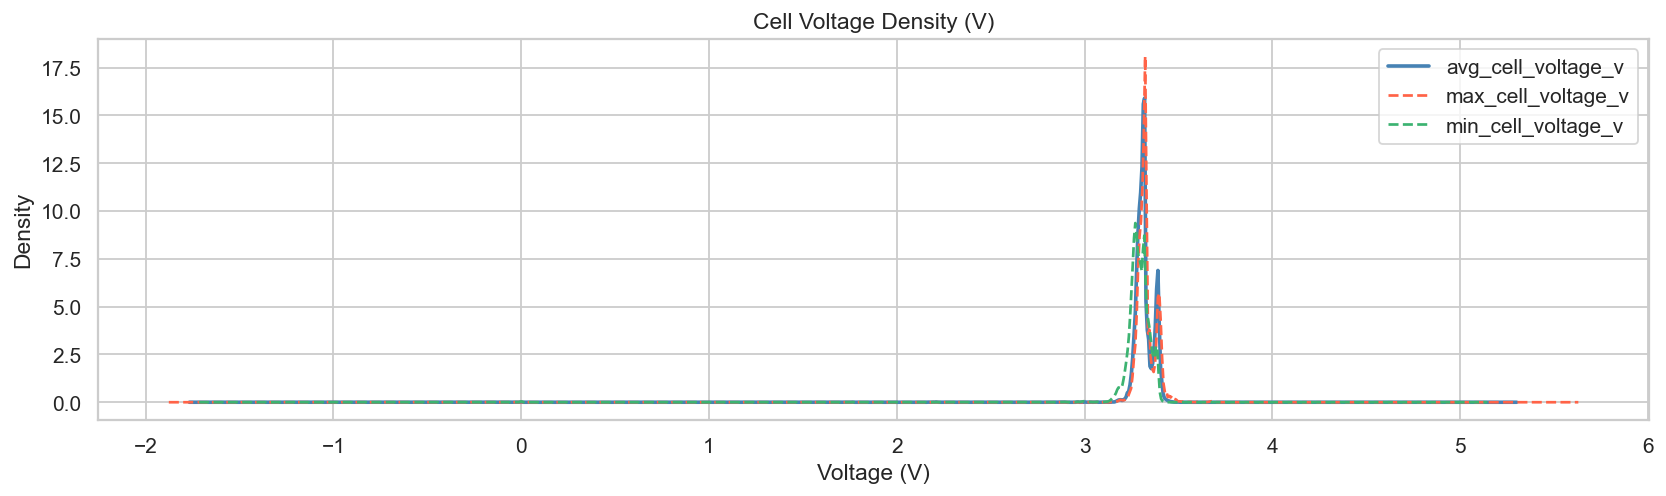

In [16]:
# avg cell voltage KDE — understand nominal operating voltage
fig, ax = plt.subplots(figsize=(13, 4))
df['avg_cell_voltage_v'].dropna().plot.kde(ax=ax, color='steelblue', linewidth=2, label='avg_cell_voltage_v')
df['max_cell_voltage_v'].dropna().plot.kde(ax=ax, color='tomato', linewidth=1.5, linestyle='--', label='max_cell_voltage_v')
df['min_cell_voltage_v'].dropna().plot.kde(ax=ax, color='mediumseagreen', linewidth=1.5, linestyle='--', label='min_cell_voltage_v')
ax.set_title('Cell Voltage Density (V)')
ax.set_xlabel('Voltage (V)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5 · Per-Module Comparison
Voltage mean and temp mean per module — spot if one module is systematically different.

In [17]:
mod_vm_cols = [f'module_{m}_voltage_mean' for m in MODULES]
pct_table(df, mod_vm_cols)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
module_1_voltage_mean,1643113.0,3.318,0.042,2.520,3.229,3.261,3.273,3.292,3.312,3.337,3.387,3.394,3.408,3.490
module_2_voltage_mean,1643112.0,3.319,0.043,2.224,3.229,3.261,3.273,3.292,3.312,3.338,3.388,3.395,3.411,3.533
module_3_voltage_mean,1643110.0,3.319,0.043,2.193,3.229,3.261,3.273,3.292,3.313,3.338,3.388,3.395,3.412,3.546
module_4_voltage_mean,1643110.0,3.319,0.044,2.224,3.229,3.261,3.273,3.292,3.313,3.338,3.389,3.395,3.415,3.594
module_5_voltage_mean,1643109.0,3.319,0.044,2.558,3.229,3.261,3.273,3.292,3.313,3.338,3.389,3.396,3.417,3.644


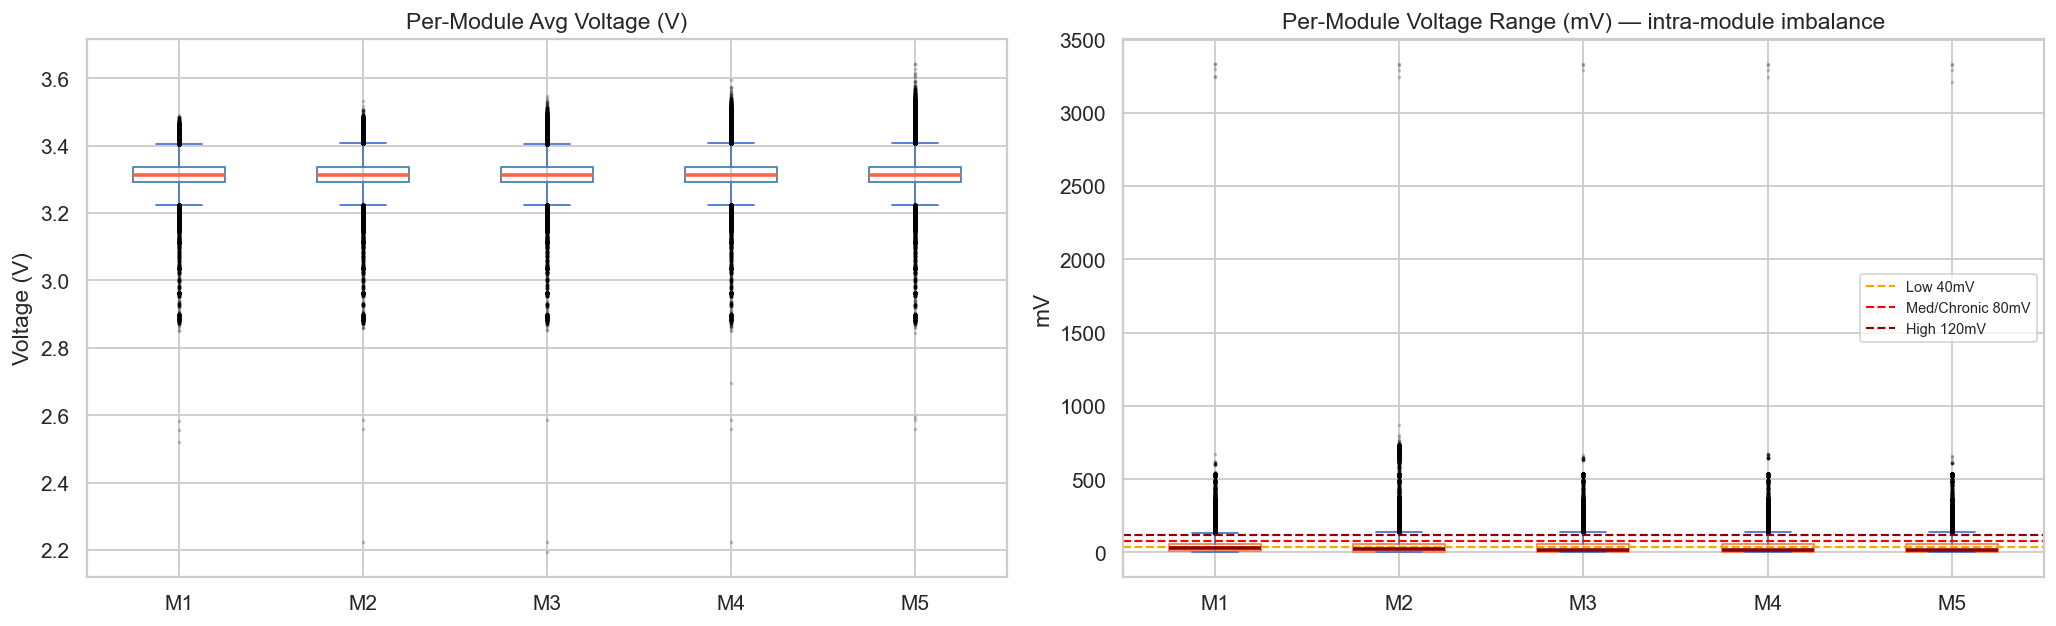

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Module voltage mean box
df[mod_vm_cols].rename(columns={f'module_{m}_voltage_mean': f'M{m}' for m in MODULES}).plot.box(
    ax=axes[0], vert=True,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='tomato', linewidth=2),
    flierprops=dict(marker='.', color='tomato', alpha=0.2, markersize=2)
)
axes[0].set_title('Per-Module Avg Voltage (V)')
axes[0].set_ylabel('Voltage (V)')

# Module voltage range (mV) box
mod_vr_mv_cols = [f'module_{m}_voltage_range_mv' for m in MODULES]
df[mod_vr_mv_cols].rename(columns={f'module_{m}_voltage_range_mv': f'M{m}' for m in MODULES}).plot.box(
    ax=axes[1], vert=True,
    boxprops=dict(color='coral'),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='.', color='coral', alpha=0.2, markersize=2)
)
axes[1].set_title('Per-Module Voltage Range (mV) — intra-module imbalance')
axes[1].set_ylabel('mV')
for val, lbl, clr in [(40,'Low','orange'),(80,'Med/Chronic','red'),(120,'High','darkred')]:
    axes[1].axhline(val, color=clr, linestyle='--', linewidth=1.2, label=f'{lbl} {val}mV')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

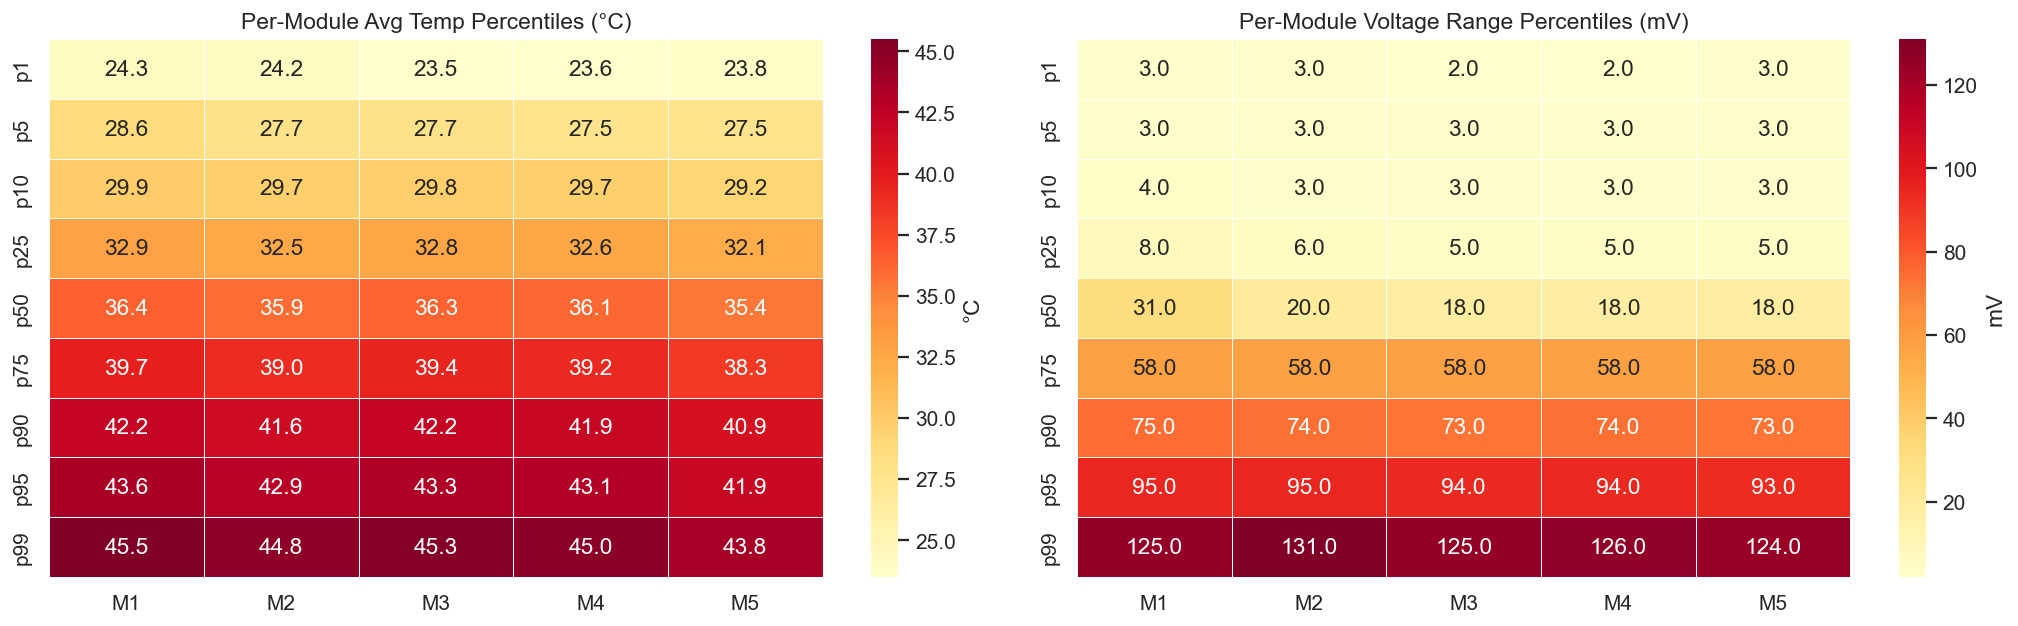

In [19]:
# Heatmap: per-module temp mean percentiles
mod_temp_data = {}
for m in MODULES:
    col = f'module_{m}_temp_mean'
    mod_temp_data[f'M{m}'] = df[col].quantile(PERCENTILES).values

heat_df = pd.DataFrame(mod_temp_data, index=PCT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label':'°C'})
axes[0].set_title('Per-Module Avg Temp Percentiles (°C)')

# Heatmap: per-module voltage range percentiles
mod_vr_data = {}
for m in MODULES:
    col = f'module_{m}_voltage_range_mv'
    mod_vr_data[f'M{m}'] = df[col].quantile(PERCENTILES).values

heat_vr_df = pd.DataFrame(mod_vr_data, index=PCT_LABELS)

sns.heatmap(heat_vr_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label':'mV'})
axes[1].set_title('Per-Module Voltage Range Percentiles (mV)')

plt.tight_layout()
plt.show()

---
## 6 · Scatter Plots — Joint Stress
Reveal how two stressors relate. Look for clusters at high-risk combinations.

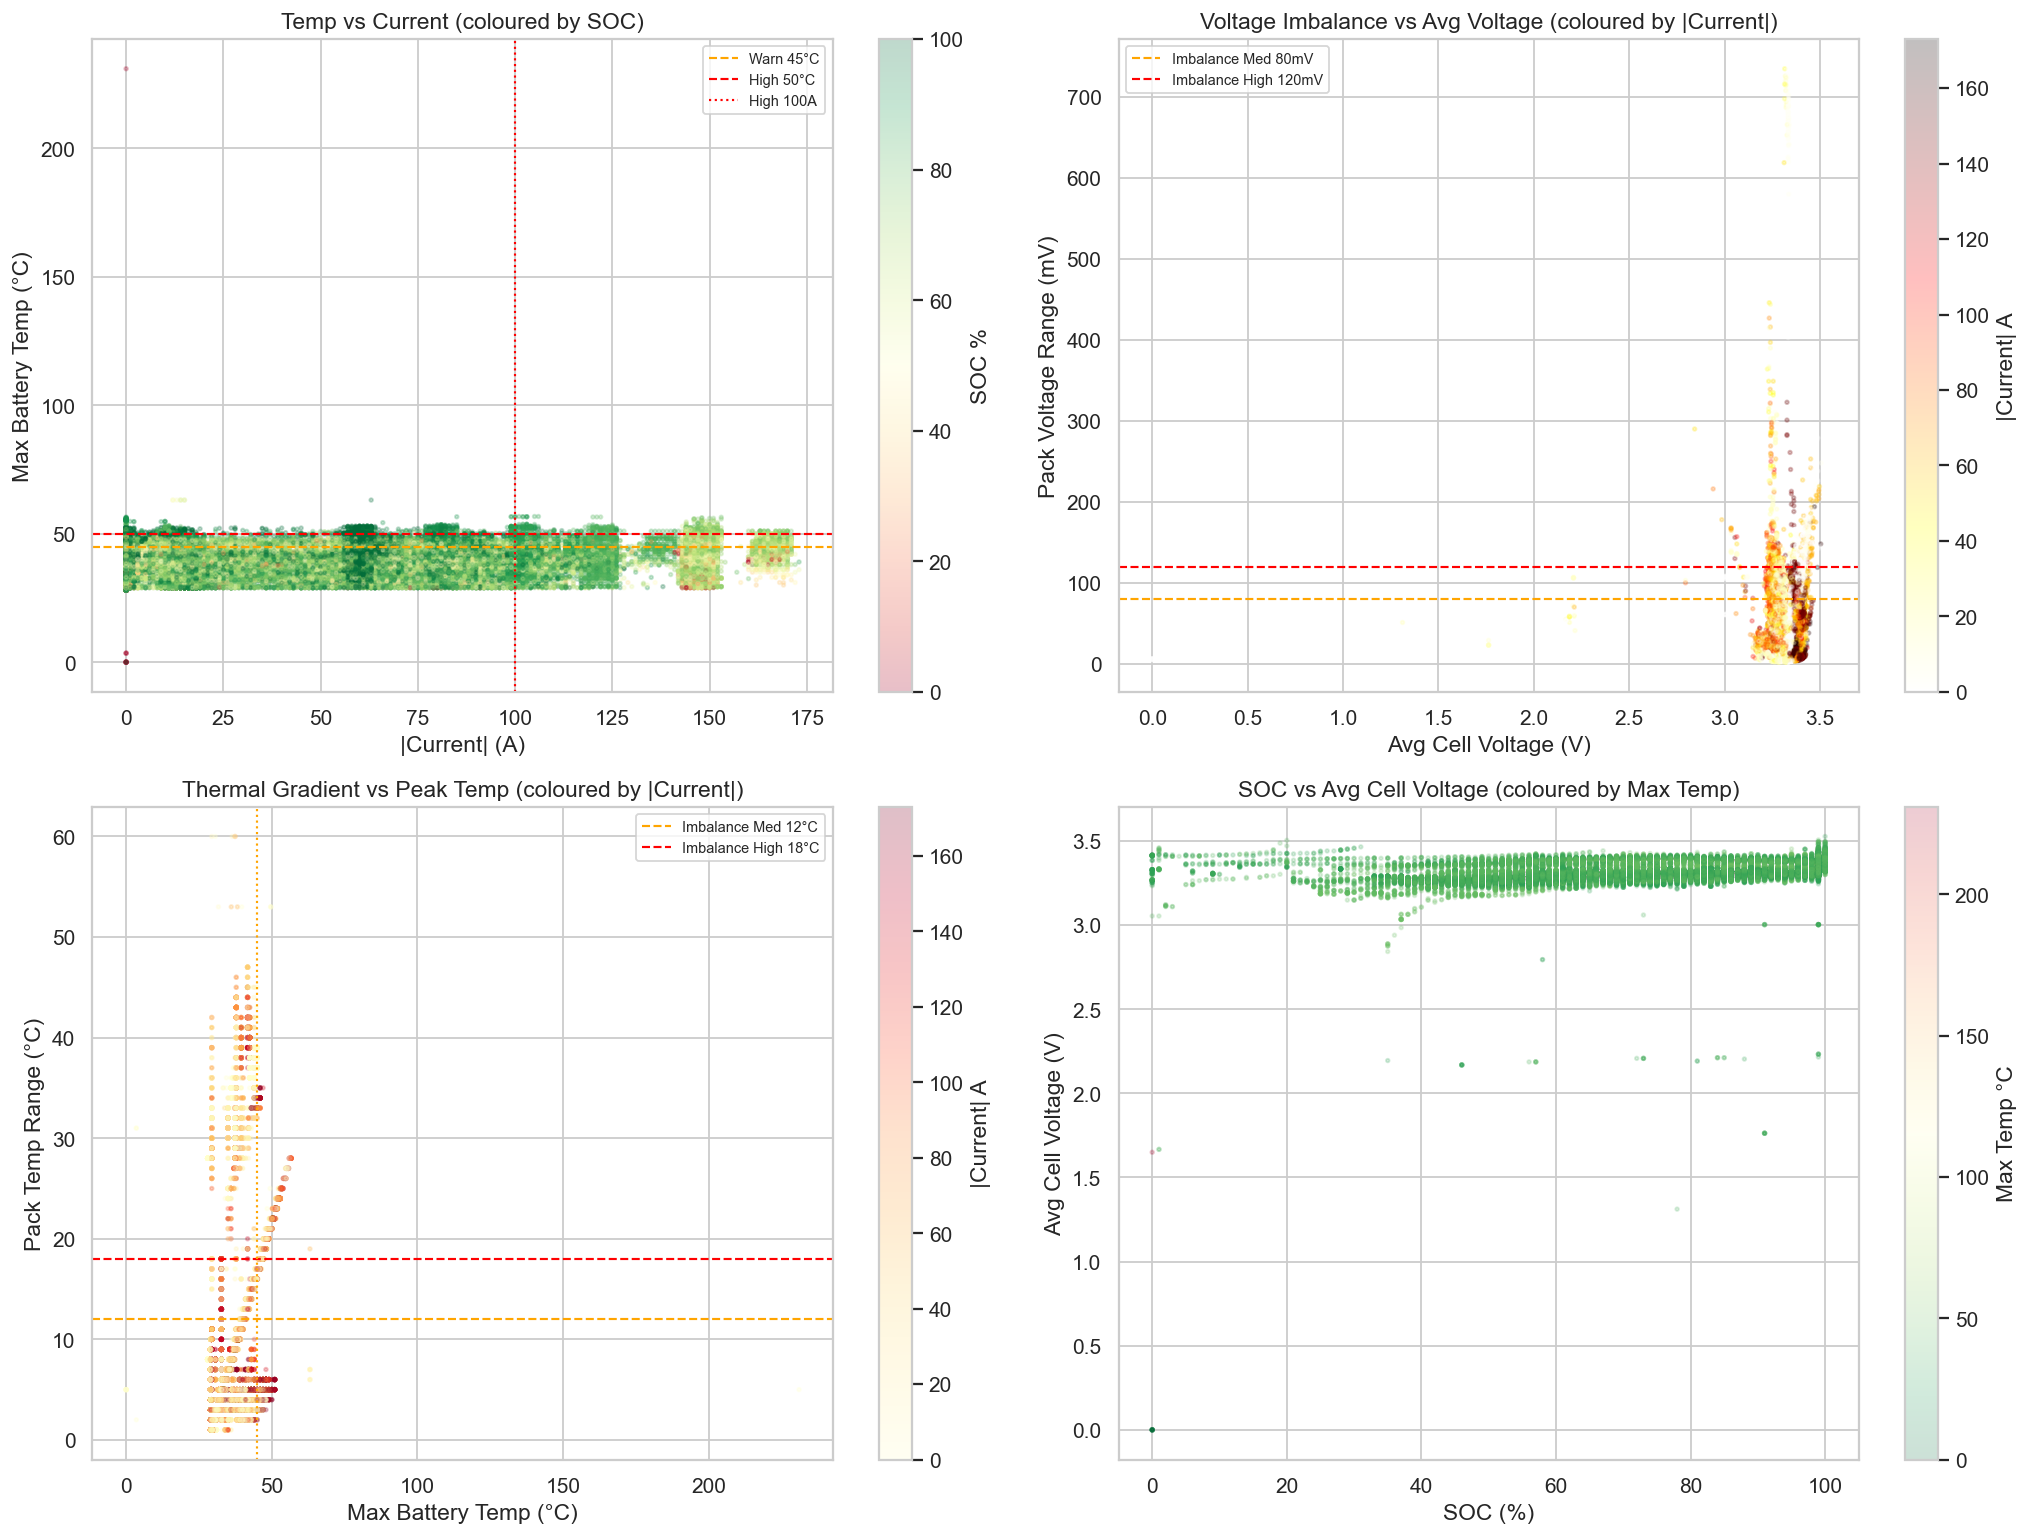

In [20]:
# Sample for speed (scatter with 1.6M points is slow)
sample = df.sample(n=min(80_000, len(df)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Max temp vs abs current
sc = axes[0,0].scatter(
    sample['abs_current_a'], sample['max_battery_temp_c'],
    c=sample['soc_pct'], cmap='RdYlGn', alpha=0.25, s=4
)
plt.colorbar(sc, ax=axes[0,0], label='SOC %')
axes[0,0].axhline(45, color='orange', linestyle='--', linewidth=1.2, label='Warn 45°C')
axes[0,0].axhline(50, color='red',    linestyle='--', linewidth=1.2, label='High 50°C')
axes[0,0].axvline(100, color='red',   linestyle=':', linewidth=1.2, label='High 100A')
axes[0,0].set_xlabel('|Current| (A)')
axes[0,0].set_ylabel('Max Battery Temp (°C)')
axes[0,0].set_title('Temp vs Current (coloured by SOC)')
axes[0,0].legend(fontsize=8)

# 2. Pack voltage range vs avg cell voltage
sc2 = axes[0,1].scatter(
    sample['avg_cell_voltage_v'], sample['pack_voltage_range_mv'],
    c=sample['abs_current_a'], cmap='hot_r', alpha=0.25, s=4
)
plt.colorbar(sc2, ax=axes[0,1], label='|Current| A')
axes[0,1].axhline(80, color='orange', linestyle='--', linewidth=1.2, label='Imbalance Med 80mV')
axes[0,1].axhline(120,color='red',    linestyle='--', linewidth=1.2, label='Imbalance High 120mV')
axes[0,1].set_xlabel('Avg Cell Voltage (V)')
axes[0,1].set_ylabel('Pack Voltage Range (mV)')
axes[0,1].set_title('Voltage Imbalance vs Avg Voltage (coloured by |Current|)')
axes[0,1].legend(fontsize=8)

# 3. Pack temp range vs max temp
sc3 = axes[1,0].scatter(
    sample['max_battery_temp_c'], sample['pack_temp_range'],
    c=sample['abs_current_a'], cmap='YlOrRd', alpha=0.25, s=4
)
plt.colorbar(sc3, ax=axes[1,0], label='|Current| A')
axes[1,0].axhline(12, color='orange', linestyle='--', linewidth=1.2, label='Imbalance Med 12°C')
axes[1,0].axhline(18, color='red',    linestyle='--', linewidth=1.2, label='Imbalance High 18°C')
axes[1,0].axvline(45, color='orange', linestyle=':',  linewidth=1.2)
axes[1,0].set_xlabel('Max Battery Temp (°C)')
axes[1,0].set_ylabel('Pack Temp Range (°C)')
axes[1,0].set_title('Thermal Gradient vs Peak Temp (coloured by |Current|)')
axes[1,0].legend(fontsize=8)

# 4. SOC vs avg cell voltage
sc4 = axes[1,1].scatter(
    sample['soc_pct'], sample['avg_cell_voltage_v'],
    c=sample['max_battery_temp_c'], cmap='RdYlGn_r', alpha=0.2, s=4
)
plt.colorbar(sc4, ax=axes[1,1], label='Max Temp °C')
axes[1,1].set_xlabel('SOC (%)')
axes[1,1].set_ylabel('Avg Cell Voltage (V)')
axes[1,1].set_title('SOC vs Avg Cell Voltage (coloured by Max Temp)')

plt.tight_layout()
plt.show()

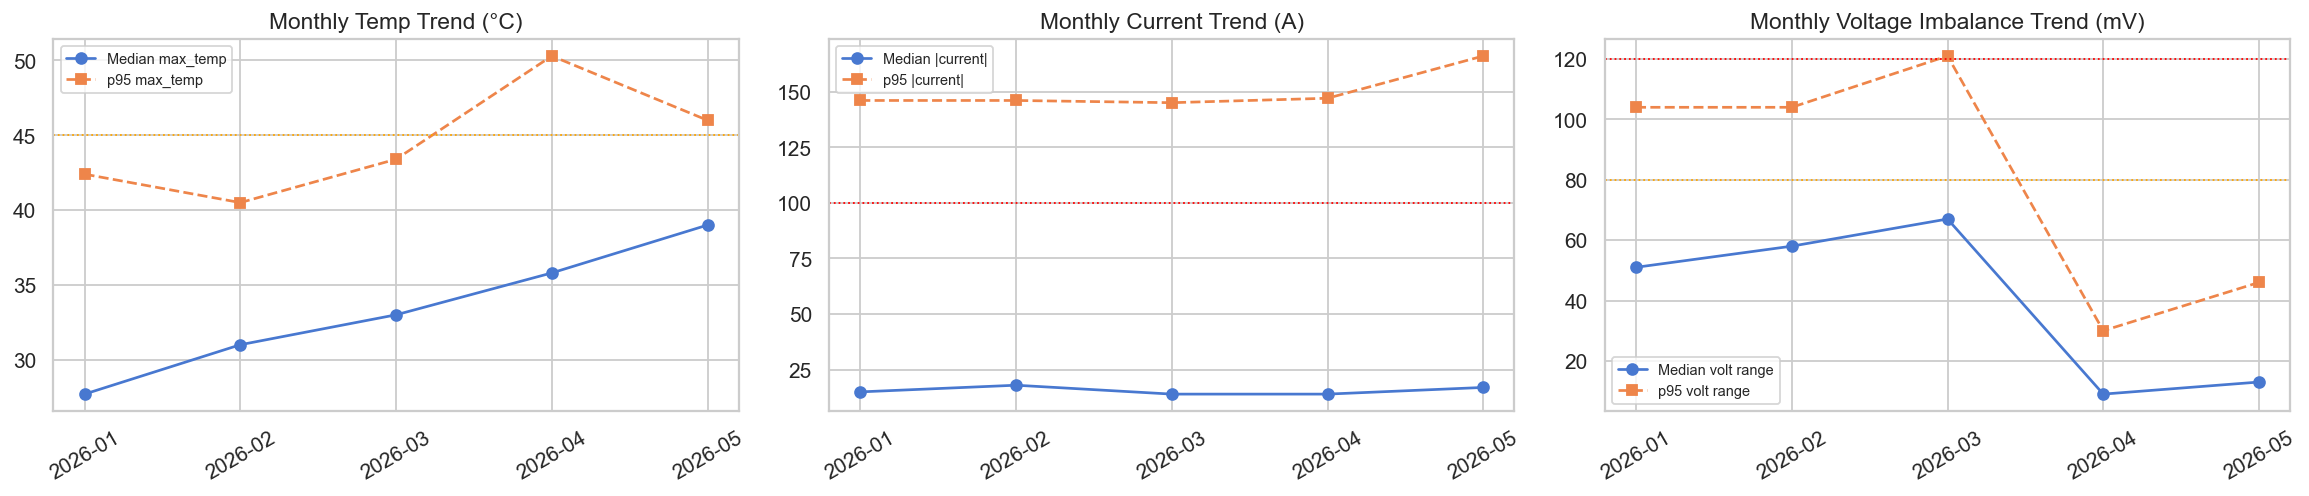

In [21]:
# Time-series: monthly median of key metrics
df['month'] = df['timestamp'].dt.to_period('M')
monthly = df.groupby('month').agg(
    avg_temp=('avg_battery_temp_c','median'),
    max_temp=('max_battery_temp_c','p95' if False else lambda x: x.quantile(0.95)),
    avg_current=('abs_current_a','median'),
    p95_current=('abs_current_a', lambda x: x.quantile(0.95)),
    avg_vrange_mv=('pack_voltage_range_mv','median'),
    p95_vrange_mv=('pack_voltage_range_mv', lambda x: x.quantile(0.95)),
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(monthly['month_str'], monthly['avg_temp'], marker='o', label='Median max_temp')
axes[0].plot(monthly['month_str'], monthly['max_temp'], marker='s', linestyle='--', label='p95 max_temp')
axes[0].axhline(45, color='orange', linestyle=':', linewidth=1)
axes[0].set_title('Monthly Temp Trend (°C)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)

axes[1].plot(monthly['month_str'], monthly['avg_current'], marker='o', label='Median |current|')
axes[1].plot(monthly['month_str'], monthly['p95_current'], marker='s', linestyle='--', label='p95 |current|')
axes[1].axhline(100, color='red', linestyle=':', linewidth=1)
axes[1].set_title('Monthly Current Trend (A)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

axes[2].plot(monthly['month_str'], monthly['avg_vrange_mv'], marker='o', label='Median volt range')
axes[2].plot(monthly['month_str'], monthly['p95_vrange_mv'], marker='s', linestyle='--', label='p95 volt range')
axes[2].axhline(80, color='orange', linestyle=':', linewidth=1)
axes[2].axhline(120, color='red', linestyle=':', linewidth=1)
axes[2].set_title('Monthly Voltage Imbalance Trend (mV)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7 · Outlier Deep-Dive
Identify and count extreme rows — useful for validating or tightening alert thresholds.

In [22]:
# Define extreme bands for each key metric
extremes = {
    'max_battery_temp_c > 50°C'     : df['max_battery_temp_c'] > 50,
    'max_battery_temp_c > 55°C'     : df['max_battery_temp_c'] > 55,
    'abs_current_a > 100A'          : df['abs_current_a'] > 100,
    'abs_current_a > 180A'          : df['abs_current_a'] > 180,
    'pack_voltage_range_mv > 120mV' : df['pack_voltage_range_mv'] > 120,
    'pack_temp_range > 12°C'        : df['pack_temp_range'] > 12,
    'pack_temp_range > 18°C'        : df['pack_temp_range'] > 18,
    'cell_spread_mv > 100mV'        : df['cell_spread_mv'] > 100,
    'fault_any = 1'                 : df['fault_any'] == 1,
}

rows = []
for label, mask in extremes.items():
    rows.append({'condition': label, 'count': int(mask.sum()), 'pct_of_total': round(100*mask.sum()/len(df), 2)})
extreme_df = pd.DataFrame(rows).set_index('condition')
print(extreme_df.to_string())

                                count  pct_of_total
condition                                          
max_battery_temp_c > 50°C       30066          1.83
max_battery_temp_c > 55°C        1369          0.08
abs_current_a > 100A           230788         14.05
abs_current_a > 180A               13          0.00
pack_voltage_range_mv > 120mV   39019          2.37
pack_temp_range > 12°C         561107         34.15
pack_temp_range > 18°C         181046         11.02
cell_spread_mv > 100mV          72196          4.39
fault_any = 1                   79437          4.83


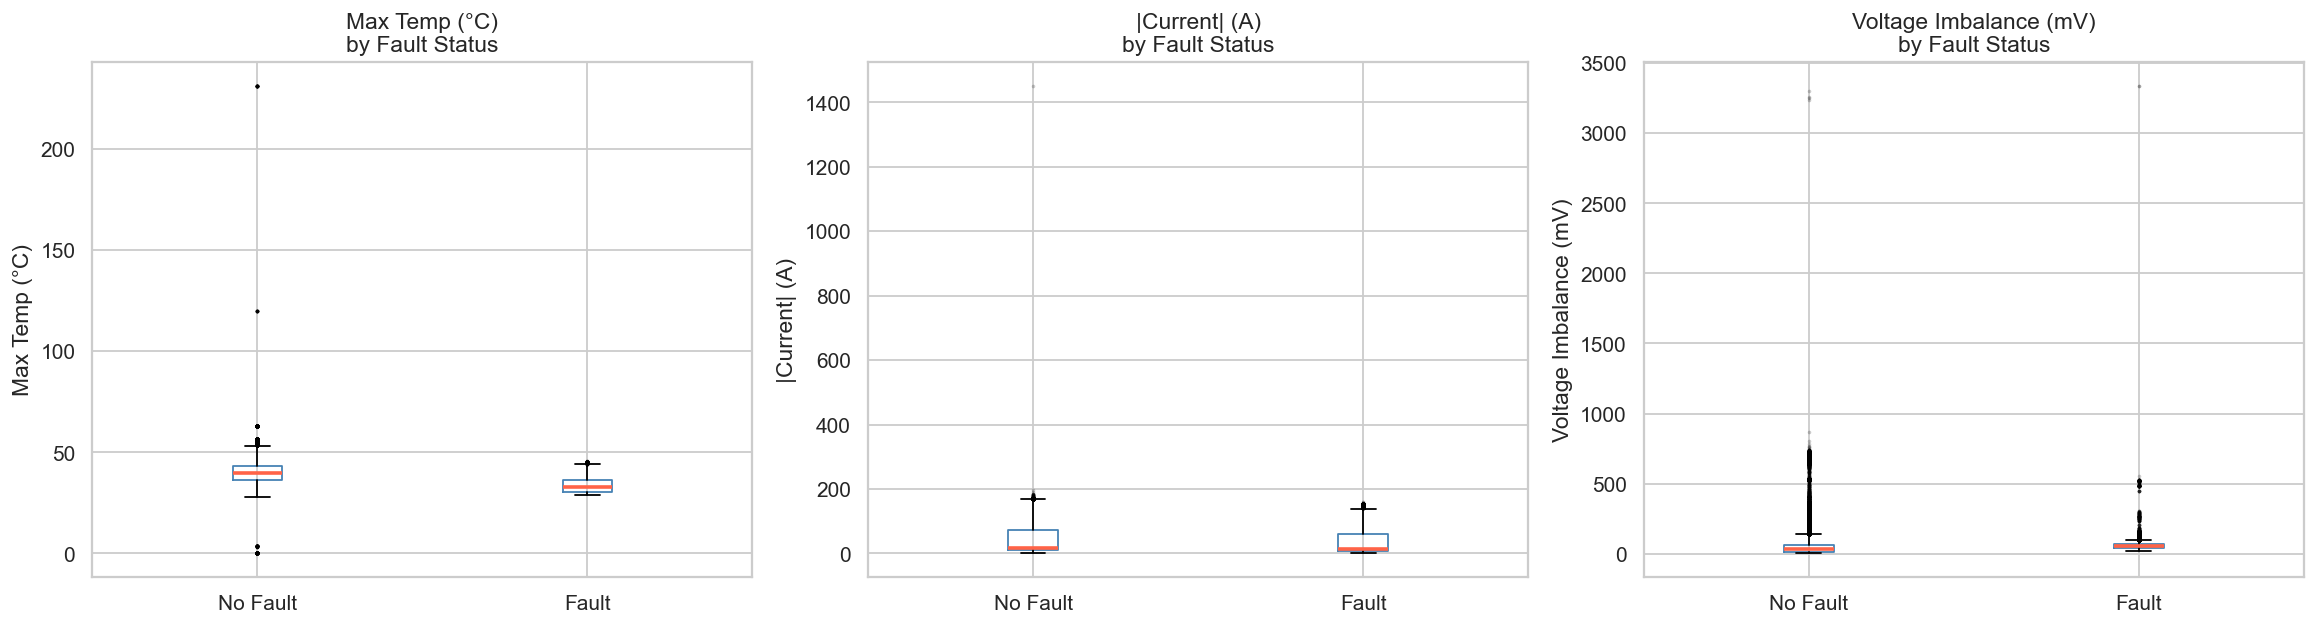

In [23]:
# Box plots split by fault_any — does fault correlate with higher stress?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in zip(
    axes,
    ['max_battery_temp_c','abs_current_a','pack_voltage_range_mv'],
    ['Max Temp (°C)','|Current| (A)','Voltage Imbalance (mV)']
):
    groups = [df[df['fault_any']==v][col].dropna() for v in [0,1]]
    ax.boxplot(
        groups, labels=['No Fault','Fault'],
        boxprops=dict(color='steelblue'),
        medianprops=dict(color='tomato', linewidth=2),
        flierprops=dict(marker='.', color='tomato', alpha=0.2, markersize=2)
    )
    ax.set_title(f'{label}\nby Fault Status')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

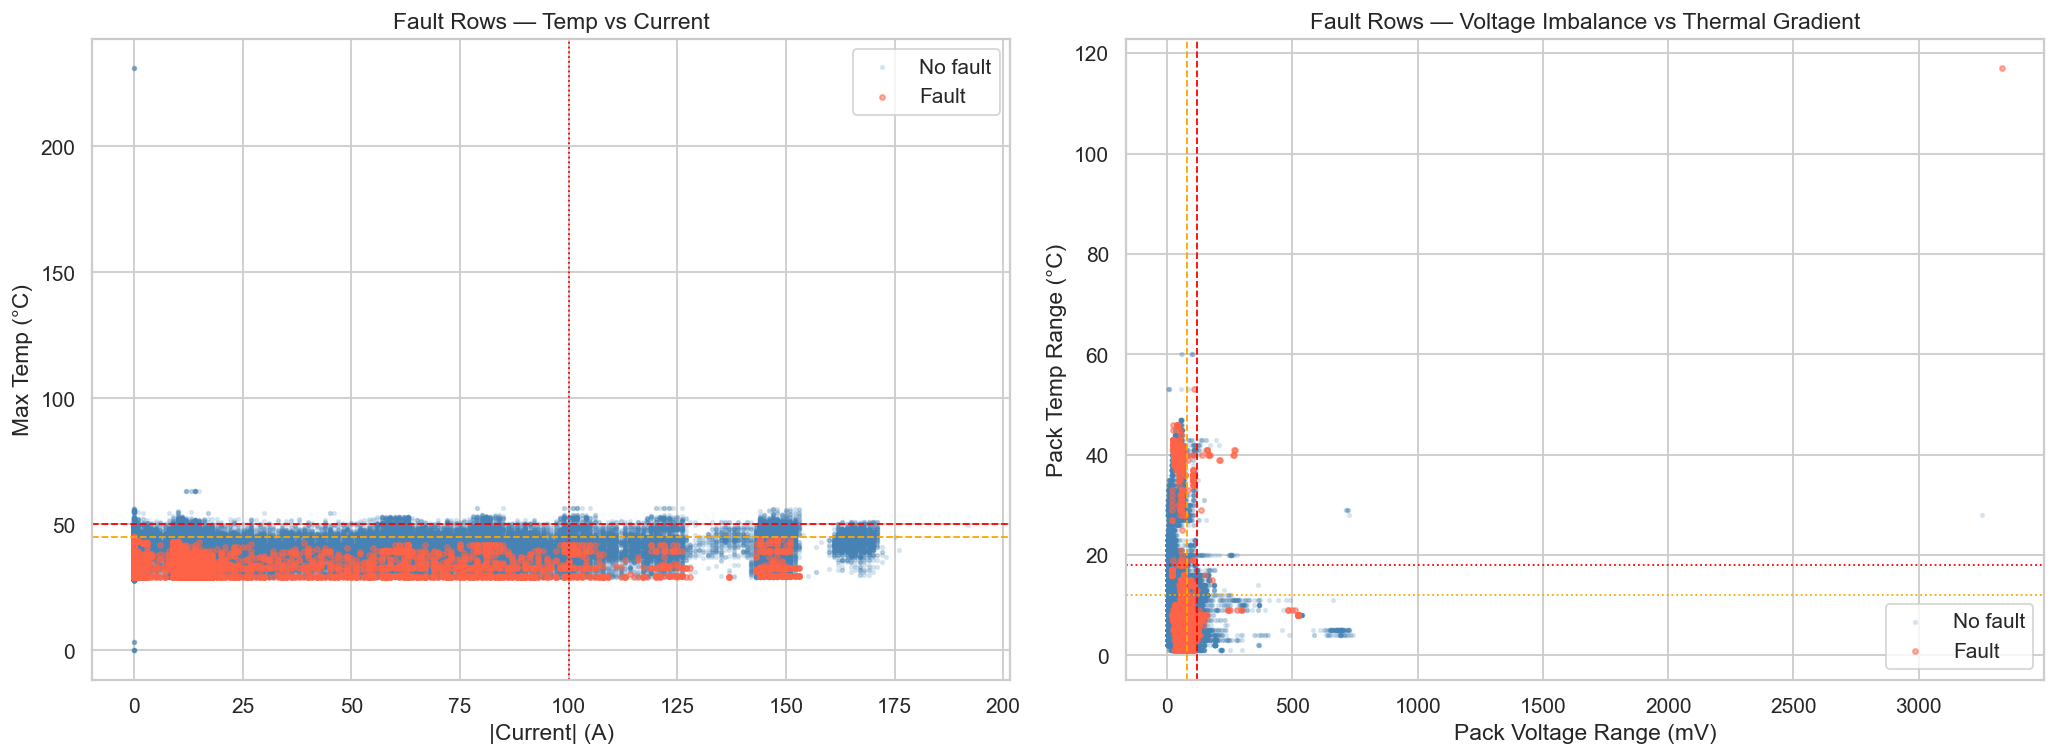

In [24]:
# Scatter: identify extreme rows visually — highlight fault points
sample_full = df.sample(n=min(100_000, len(df)), random_state=99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

no_fault = sample_full[sample_full['fault_any']==0]
fault    = sample_full[sample_full['fault_any']==1]

# Temp vs Current — fault highlighted
axes[0].scatter(no_fault['abs_current_a'], no_fault['max_battery_temp_c'],
                alpha=0.15, s=4, color='steelblue', label='No fault')
axes[0].scatter(fault['abs_current_a'], fault['max_battery_temp_c'],
                alpha=0.5, s=8, color='tomato', label='Fault')
axes[0].axhline(45, color='orange', linestyle='--', linewidth=1)
axes[0].axhline(50, color='red', linestyle='--', linewidth=1)
axes[0].axvline(100, color='red', linestyle=':', linewidth=1)
axes[0].set_xlabel('|Current| (A)')
axes[0].set_ylabel('Max Temp (°C)')
axes[0].set_title('Fault Rows — Temp vs Current')
axes[0].legend()

# Voltage imbalance vs temp range — fault highlighted
axes[1].scatter(no_fault['pack_voltage_range_mv'], no_fault['pack_temp_range'],
                alpha=0.15, s=4, color='steelblue', label='No fault')
axes[1].scatter(fault['pack_voltage_range_mv'], fault['pack_temp_range'],
                alpha=0.5, s=8, color='tomato', label='Fault')
axes[1].axvline(80, color='orange', linestyle='--', linewidth=1)
axes[1].axvline(120,color='red',    linestyle='--', linewidth=1)
axes[1].axhline(12, color='orange', linestyle=':', linewidth=1)
axes[1].axhline(18, color='red',    linestyle=':', linewidth=1)
axes[1].set_xlabel('Pack Voltage Range (mV)')
axes[1].set_ylabel('Pack Temp Range (°C)')
axes[1].set_title('Fault Rows — Voltage Imbalance vs Thermal Gradient')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8 · Threshold Review Summary
Compare current config thresholds against actual data percentiles to decide if tuning is needed.

In [25]:
def threshold_review(series, name, unit, thresholds: dict):
    """Print percentile table + show where each threshold falls in the distribution."""
    s = series.dropna()
    pcts = s.quantile(PERCENTILES)
    print(f'\n── {name} ({unit}) ──')
    print(f'   n={len(s):,}  mean={s.mean():.2f}  std={s.std():.2f}  max={s.max():.2f}')
    print('   Percentiles:')
    for lbl, val in zip(PCT_LABELS, pcts):
        print(f'     {lbl:>4} = {val:>8.2f} {unit}')
    print('   Threshold exceedance:')
    for thr_name, thr_val in thresholds.items():
        rank_pct = 100 * (s < thr_val).mean()
        exceed_n = (s > thr_val).sum()
        print(f'     {thr_name:>20} = {thr_val:>7.1f} {unit}  →  {rank_pct:.1f}th pct  ({exceed_n:,} rows exceed)')

threshold_review(
    df['max_battery_temp_c'], 'Max Battery Temp', '°C',
    {'warn': 45, 'high': 50, 'critical': 55}
)
threshold_review(
    df['pack_temp_range'], 'Pack Temp Range', '°C',
    {'low': 6, 'medium': 12, 'high': 18}
)
threshold_review(
    df['abs_current_a'], 'Abs Current', 'A',
    {'stress_low': 50, 'stress_medium': 100, 'stress_high': 180}
)
threshold_review(
    df['pack_voltage_range_mv'], 'Pack Voltage Range', 'mV',
    {'imbalance_low': 40, 'imbalance_medium': 80, 'imbalance_high': 120, 'rule_critical': 130}
)
threshold_review(
    df['cell_spread_mv'], 'Cell Spread (max−min)', 'mV',
    {'ref_40': 40, 'ref_80': 80, 'ref_120': 120}
)


── Max Battery Temp (°C) ──
   n=1,594,384  mean=39.20  std=5.43  max=231.00
   Percentiles:
       p1 =    29.00 °C
       p5 =    29.40 °C
      p10 =    31.90 °C
      p25 =    35.60 °C
      p50 =    39.20 °C
      p75 =    43.00 °C
      p90 =    46.10 °C
      p95 =    48.00 °C
      p99 =    51.10 °C
   Threshold exceedance:
                     warn =    45.0 °C  →  84.9th pct  (214,627 rows exceed)
                     high =    50.0 °C  →  97.9th pct  (30,066 rows exceed)
                 critical =    55.0 °C  →  99.9th pct  (1,369 rows exceed)

── Pack Temp Range (°C) ──
   n=1,643,116  mean=10.65  std=7.26  max=117.00
   Percentiles:
       p1 =     2.00 °C
       p5 =     3.00 °C
      p10 =     3.00 °C
      p25 =     5.00 °C
      p50 =    10.00 °C
      p75 =    14.00 °C
      p90 =    19.00 °C
      p95 =    23.00 °C
      p99 =    39.00 °C
   Threshold exceedance:
                      low =     6.0 °C  →  29.5th pct  (1,074,979 rows exceed)
                   mediu

In [26]:
# ── Final full percentile table ──────────────────────────────────────────────
all_metrics = [
    'max_battery_temp_c','avg_battery_temp_c','min_battery_temp_c','pack_temp_range',
    'abs_current_a','battery_current_a',
    'avg_cell_voltage_v','max_cell_voltage_v','min_cell_voltage_v',
    'pack_voltage_range_mv','cell_spread_mv',
    'module_1_temp_mean','module_2_temp_mean','module_3_temp_mean','module_4_temp_mean','module_5_temp_mean',
    'module_1_voltage_range_mv','module_2_voltage_range_mv','module_3_voltage_range_mv',
    'module_4_voltage_range_mv','module_5_voltage_range_mv',
    'soc_pct',
]
pct_table(df, [c for c in all_metrics if c in df.columns])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
metric,,,,,,,,,,,,,,
max_battery_temp_c,1594384.0,39.201,5.431,0.000,29.000,29.400,31.900,35.600,39.200,43.000,46.100,48.000,51.100,231.000
avg_battery_temp_c,1594373.0,33.877,4.306,0.000,22.400,25.700,28.800,31.500,34.000,36.600,39.000,41.000,44.000,74.000
min_battery_temp_c,1594384.0,28.699,5.256,0.000,11.000,20.400,28.000,28.000,28.000,28.000,37.000,39.000,42.000,46.000
pack_temp_range,1643116.0,10.653,7.259,1.000,2.000,3.000,3.000,5.000,10.000,14.000,19.000,23.000,39.000,117.000
abs_current_a,1634544.0,43.571,46.987,0.000,0.000,0.000,0.000,11.000,15.000,73.000,122.000,147.000,165.000,1451.000
battery_current_a,1634544.0,43.571,46.987,0.000,0.000,0.000,0.000,11.000,15.000,73.000,122.000,147.000,165.000,1451.000
avg_cell_voltage_v,1524505.0,3.318,0.060,0.000,3.226,3.260,3.273,3.291,3.313,3.339,3.388,3.395,3.412,3.534
max_cell_voltage_v,1524505.0,3.329,0.058,0.000,3.236,3.267,3.281,3.300,3.320,3.348,3.398,3.409,3.465,3.753
min_cell_voltage_v,1524505.0,3.290,0.096,0.000,3.157,3.212,3.234,3.262,3.291,3.321,3.358,3.380,3.391,3.430
